In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

In [201]:
df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")

In [202]:
df.head()

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    504 non-null    object 
 1   FB      504 non-null    float64
 2   GOOG    504 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.9+ KB


In [204]:
# changing date type to datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    504 non-null    datetime64[ns]
 1   FB      504 non-null    float64       
 2   GOOG    504 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 11.9 KB


In [206]:
df.head()

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68


## Task 1

In [207]:
# TODO verify
# relative income

fb_daily_returns = df["FB"].shift(-1) / df["FB"] - 1
goog_daily_returns = df["GOOG"].shift(-1) / df["GOOG"] - 1

fb_daily_mean = fb_daily_returns.mean()
fb_daily_std = fb_daily_returns.std()
print(f"FB daily return mean: {fb_daily_mean} and standard deviation: {fb_daily_std}")

goog_daily_mean = goog_daily_returns.mean()
goog_daily_std = goog_daily_returns.std()
print(f"GOOG daily return mean: {goog_daily_mean} and standard deviation: {goog_daily_std}")

FB daily return mean: 0.0009045706094875624 and standard deviation: 0.017050472043500107
GOOG daily return mean: 0.0008903930946407605 and standard deviation: 0.015894471452196062


In [208]:
# # TODO verify
# # absolute income
# 
# fb_daily_returns = df["FB"].shift(-1) / df["FB"]
# goog_daily_returns = df["GOOG"].shift(-1) - df["GOOG"]
# 
# fb_daily_mean = fb_daily_returns.mean()
# fb_daily_std = fb_daily_returns.std()
# print(f"FB daily return mean: {fb_daily_mean} and standard deviation: {fb_daily_std}")
# 
# goog_daily_mean = goog_daily_returns.mean()
# goog_daily_std = goog_daily_returns.std()
# print(f"GOOG daily return mean: {goog_daily_mean} and standard deviation: {goog_daily_std}")

## Task 2

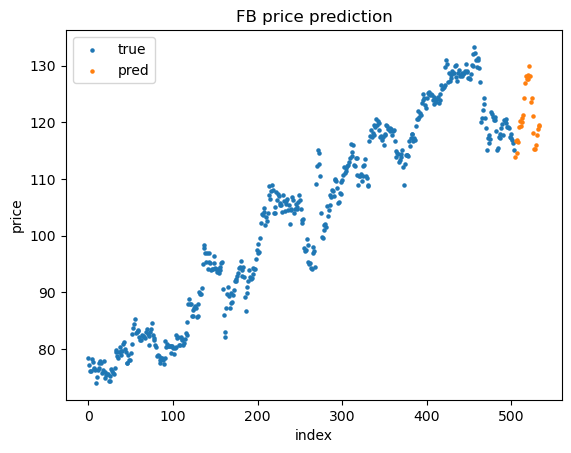

In [209]:
days = 30

fb_returns_pred = np.random.normal(
    loc=fb_daily_mean, 
    scale=fb_daily_std, 
    size=days
)

fb_last_price = df["FB"].iloc[-1]
fb_price_pred = fb_last_price * np.cumprod(1 + fb_returns_pred)

idx_start = df.index[-1] + 1
idx_end = idx_start + days
pred_index = np.arange(idx_start, idx_end)

plt.scatter(df.index, df["FB"], s=5)
plt.scatter(pred_index, fb_price_pred, s=5)
plt.legend(["true", "pred"])
plt.xlabel("index")
plt.ylabel("price")
plt.title("FB price prediction")
plt.show()


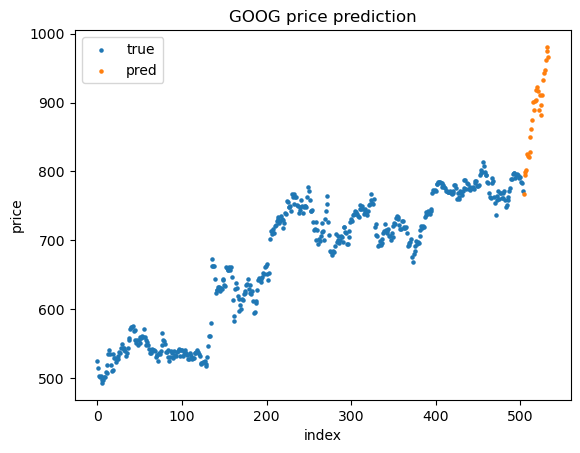

In [210]:
goog_returns_pred = np.random.normal(
    loc=goog_daily_mean, 
    scale=goog_daily_std, 
    size=days
)

goog_last_price = df["GOOG"].iloc[-1]
goog_price_pred = goog_last_price * np.cumprod(1 + goog_returns_pred)

plt.scatter(df.index, df["GOOG"], s=5)
plt.scatter(pred_index, goog_price_pred, s=5)
plt.legend(["true", "pred"])
plt.xlabel("index")
plt.ylabel("price")
plt.title("GOOG price prediction")
plt.show()

In [211]:
# # TODO price simulation (normal assumption?)
# 
# days = 30
# 
# fb_returns_pred = np.random.normal(loc=fb_daily_mean, scale=fb_daily_std, size=days)
# fb_returns_cum = np.cumsum(fb_returns_pred)
# fb_last_price = df["FB"].iloc[-1]
# fb_price_pred = fb_last_price + fb_returns_cum
# 
# idx_start = df.index[-1] + 1
# idx_end = idx_start + days
# pred_index = np.arange(idx_start, idx_end)
# 
# plt.scatter(df.index, df["FB"], s=5)
# plt.scatter(pred_index, fb_price_pred, s=5)
# plt.legend(["true", "pred"])
# plt.xlabel("index")
# plt.ylabel("price")
# plt.title("FB price prediction")
# plt.show()
# 
# 
# goog_returns_pred = np.random.normal(loc=goog_daily_mean, scale=goog_daily_std, size=days)
# goog_returns_cum = np.cumsum(goog_returns_pred)
# goog_last_price = df["GOOG"].iloc[-1]
# goog_price_pred = goog_last_price + goog_returns_cum
# 
# plt.scatter(df.index, df["GOOG"], s=5)
# plt.scatter(pred_index, goog_price_pred, s=5)
# plt.legend(["true", "pred"])
# plt.xlabel("index")
# plt.ylabel("price")
# plt.title("GOOG price prediction")
# plt.show()

## Task 3

In [212]:
def predict_price(mean, std, days, last_price):
    returns_pred = np.random.normal(loc=mean, scale=std, size=days)
    price_pred = last_price * np.cumprod(1 + returns_pred)
    return price_pred


# def predict_price(mean, std, days, last_price):
#     returns_pred = np.random.normal(loc=mean, scale=std, size=days)
#     returns_cum = np.cumsum(returns_pred)
#     price_pred = last_price + returns_cum
#     return price_pred

In [213]:
days = 60
n = 1000
goog_last_price = df["GOOG"].iloc[-1]
exp_sum = 0

for i in range(n):
    preds = predict_price(goog_daily_mean, goog_daily_std, days, goog_last_price)
    pred = preds[-1]
    exp_sum += pred

avg_price = exp_sum / n

print(f"Average GOOG ending price after {days} days is {avg_price}")

Average GOOG ending price after 60 days is 815.6340188040733


## Task 4

In [214]:
days = 30
n = 1000
fb_last_price = df["FB"].iloc[-1]
exceed_count = 0

EXCEED_THRESHOLD = 150

for i in range(n):
    preds = predict_price(fb_daily_mean, fb_daily_std, days, fb_last_price)
    pred = preds[-1]
    if pred > EXCEED_THRESHOLD:
        exceed_count += 1

exceed_prob = exceed_count / n

print(f"Probability of FB price exceeding {EXCEED_THRESHOLD} after {days} days is {exceed_prob:.5f}")

Probability of FB price exceeding 150 after 30 days is 0.00200


## Task 5

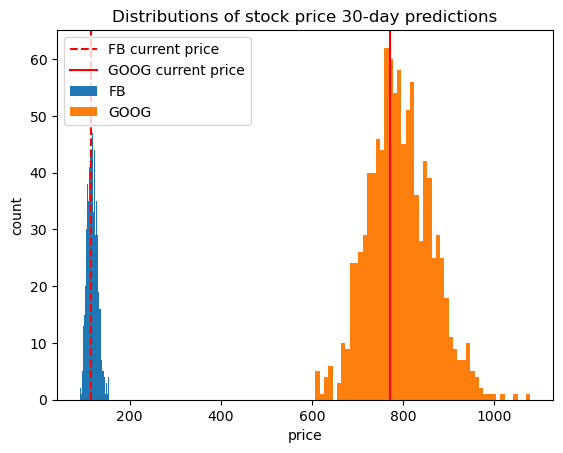

In [215]:
days = 30
n = 1000

goog_last_price = df["GOOG"].iloc[-1]
goog_preds = []

for i in range(n):
    preds = predict_price(goog_daily_mean, goog_daily_std, days, goog_last_price)
    pred = preds[-1]
    goog_preds.append(pred)

    
fb_last_price = df["FB"].iloc[-1]
fb_preds = []

for i in range(n):
    preds = predict_price(fb_daily_mean, fb_daily_std, days, fb_last_price)
    pred = preds[-1]
    fb_preds.append(pred)

plt.hist(fb_preds, bins=50)
plt.hist(goog_preds, bins=50)
plt.axline((fb_last_price, 0), (fb_last_price, 1), color="red", linestyle="--")
plt.axline((goog_last_price, 0), (goog_last_price, 1), color="red", linestyle="-")
plt.legend(["FB current price", "GOOG current price", "FB", "GOOG"])
plt.xlabel("price")
plt.ylabel("count")
plt.title(f"Distributions of stock price {days}-day predictions")
plt.show()

# higher volatility - GOOG
# potential upside - GOOG

## Task 6

In [216]:
target_power = 0.8
num_sim = 1000

max_days = len(fb_daily_returns)

days = 100
while days < max_days:
    count_sig = 0
    
    for _ in range(num_sim):
        fb_sample = np.random.choice(fb_daily_returns, days, replace=True)
        goog_sample = np.random.choice(goog_daily_returns, days, replace=True)
        
        stat, p = ttest_ind(fb_sample, goog_sample)
        
        if p < 0.05:
            count_sig += 1
    
    power = count_sig / num_sim
    
    if power >= target_power:
        print(f"Required number of days: {days}")
        print(f"Achieved power: {power:.3f}")
        break
    days += 50
    print(f"Increasing sample size to {days}, power: {power:.3f}")
    
# we couldn't find such a sample size
# with increasing sample size, prob of rejecting null hypothesis goes to 0
# no statistical difference in daily returns

Increasing sample size to 150, power: 0.039
Increasing sample size to 200, power: 0.012
Increasing sample size to 250, power: 0.017
Increasing sample size to 300, power: 0.014
Increasing sample size to 350, power: 0.015
Increasing sample size to 400, power: 0.010
Increasing sample size to 450, power: 0.013
Increasing sample size to 500, power: 0.015
Increasing sample size to 550, power: 0.010


## Task 7

n=20, power=0.020
n=40, power=0.010
n=60, power=0.090
n=80, power=0.100
n=100, power=0.110
n=120, power=0.100
n=140, power=0.090
n=160, power=0.060
n=180, power=0.060
n=200, power=0.100
n=220, power=0.090
n=240, power=0.070
n=260, power=0.070
n=280, power=0.040
n=300, power=0.110
n=320, power=0.110
n=340, power=0.150
n=360, power=0.100
n=380, power=0.100
n=400, power=0.030
n=420, power=0.080
n=440, power=0.090
n=460, power=0.070
n=480, power=0.060
n=500, power=0.050
n=520, power=0.050
n=540, power=0.030
n=560, power=0.070
n=580, power=0.070
n=600, power=0.010
n=620, power=0.020
n=640, power=0.030
n=660, power=0.060
n=680, power=0.010
n=700, power=0.000
n=720, power=0.060
n=740, power=0.050
n=760, power=0.040
n=780, power=0.010
n=800, power=0.010
n=820, power=0.010
n=840, power=0.020
n=860, power=0.010
n=880, power=0.000
n=900, power=0.050
n=920, power=0.000
n=940, power=0.020
n=960, power=0.010
n=980, power=0.020


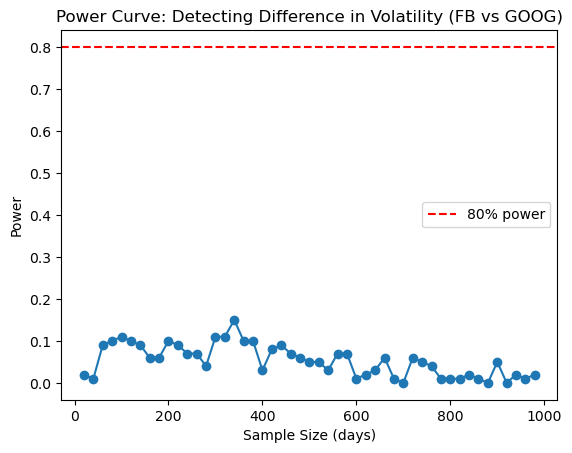

In [217]:
from scipy.stats import f
from scipy.stats import levene

num_sim = 100
alpha = 0.05

sample_sizes = range(20, 1000, 20)
powers = []

for days in sample_sizes:
    count_reject = 0
    
    for _ in range(num_sim):
        fb_sample = np.random.choice(fb_daily_returns, days, replace=True)
        goog_sample = np.random.choice(goog_daily_returns, days, replace=True)
        
        # var_fb = np.var(fb_s, ddof=1)
        # var_goog = np.var(goog_s, ddof=1)
        # 
        # F_stat = var_fb / var_goog
        # 
        # F_low  = f.ppf(alpha/2, n-1, n-1)
        # F_high = f.ppf(1 - alpha/2, n-1, n-1)
        # 
        # if F_stat < F_low or F_stat > F_high:
        #     count_reject += 1
            
        stat, p = levene(fb_sample, goog_sample)
        if p < 0.05:
            count_reject += 1
    
    power = count_reject / num_sim
    powers.append(power)
    print(f"n={days}, power={power:.3f}")

plt.plot(sample_sizes, powers, marker='o')
plt.axhline(0.8, color='red', linestyle='--', label='80% power')
plt.xlabel("Sample Size (days)")
plt.ylabel("Power")
plt.title("Power Curve: Detecting Difference in Volatility (FB vs GOOG)")
plt.legend()
plt.show()

## Task 8

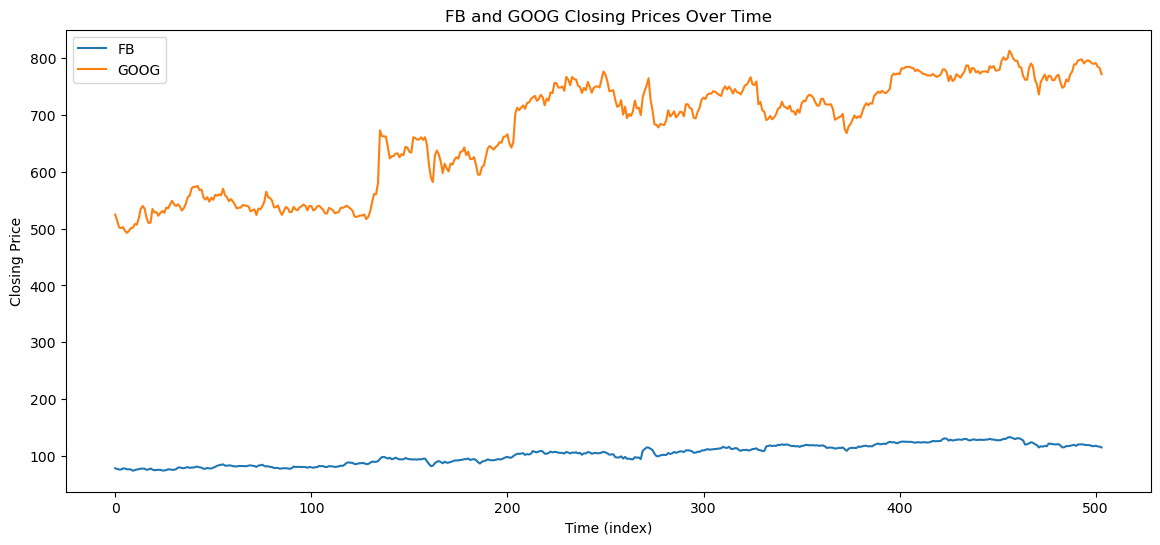

In [218]:
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(14,6))
plt.plot(df.index, df['FB'], label='FB')
plt.plot(df.index, df['GOOG'], label='GOOG')
plt.xlabel('Time (index)')
plt.ylabel('Closing Price')
plt.title('FB and GOOG Closing Prices Over Time')
plt.legend()
plt.show()


In [219]:
# Convert to a pandas Series with datetime index if available
# Here we assume df.index is already datetime or integer sequence

# Decompose FB
fb_decomp = seasonal_decompose(df['FB'], model='multiplicative', period=30)  # period=30 ~ monthly

# Decompose GOOG
goog_decomp = seasonal_decompose(df['GOOG'], model='multiplicative', period=30)


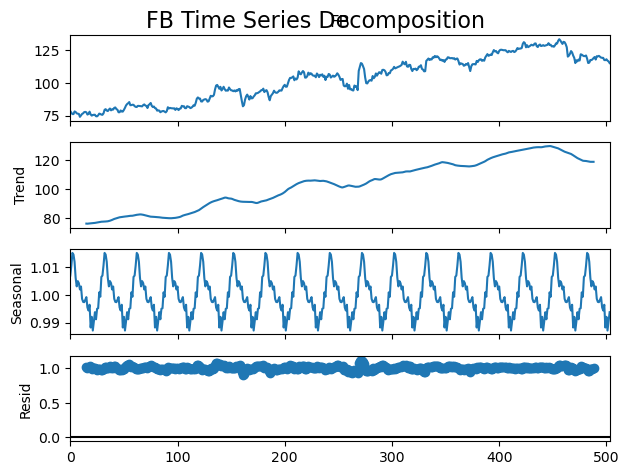

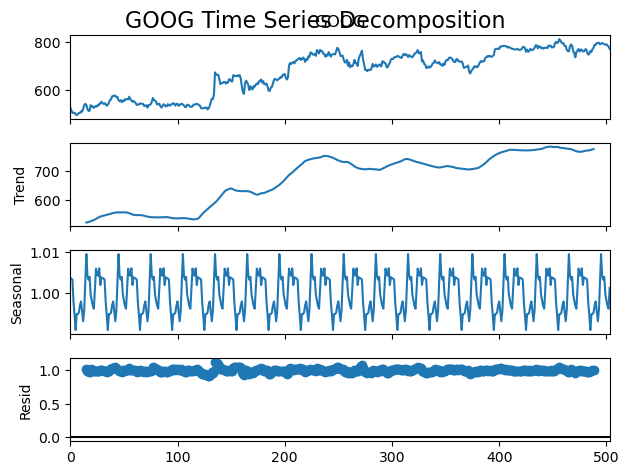

In [220]:
# FB decomposition
fb_decomp.plot()
plt.suptitle('FB Time Series Decomposition', fontsize=16)
plt.show()

# GOOG decomposition
goog_decomp.plot()
plt.suptitle('GOOG Time Series Decomposition', fontsize=16)
plt.show()


## Task 9

In [231]:
from statsmodels.tsa.arima.model import ARIMA

fb_prices = df["FB"]

model = ARIMA(fb_prices, order=(1,1,1))
model_fit = model.fit()

forecast_steps = 10
forecast_result = model_fit.forecast(steps=forecast_steps)

print(forecast_result)

504    114.975278
505    114.975072
506    114.975072
507    114.975072
508    114.975072
509    114.975072
510    114.975072
511    114.975072
512    114.975072
513    114.975072
Name: predicted_mean, dtype: float64


## Task 10

In [232]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ETS

model = ETS(df['GOOG'], trend='add', seasonal=None, initialization_method="estimated")

model_fit = model.fit()
forecast = model_fit.forecast(steps=10)

print(forecast)

504    772.309837
505    772.799673
506    773.289510
507    773.779346
508    774.269183
509    774.759019
510    775.248856
511    775.738692
512    776.228529
513    776.718366
dtype: float64
